<a href="https://colab.research.google.com/github/siddhiofficial/Siddhi/blob/main/EDA_Phase1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Siddhi J Salunkhe
#23BDS0243
#EDA Course Project: Phase 1

#Importing and Loading dataset

In [33]:
from google.colab import files
uploaded = files.upload()

Saving NaturalGas.csv to NaturalGas (1).csv


#Reading the dataset

In [34]:
import pandas as pd

df = pd.read_csv("NaturalGas.csv")
df.head()

,rownames,state,statecode,year,consumption,price,eprice,oprice,lprice,heating,income
0,1,NY,35,1967,313656,1.42,2.98,7.40,1.47,6262,10903.75
1,2,NY,35,1968,319282,1.38,2.91,7.77,1.42,6125,11370.02
2,3,NY,35,1969,331326,1.37,2.84,7.96,1.38,6040,11578.68
3,4,NY,35,1970,346533,1.40,2.87,8.33,1.37,6085,11586.77
4,5,NY,35,1971,352085,1.50,3.07,8.80,1.40,5907,11657.42


#Basic Statistical Analysis

In [35]:
df.info()

df.describe(include='all')

df.shape

df.columns

df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138 entries, 0 to 137
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   rownames     138 non-null    int64  
 1   state        138 non-null    object 
 2   statecode    138 non-null    int64  
 3   year         138 non-null    int64  
 4   consumption  138 non-null    int64  
 5   price        138 non-null    float64
 6   eprice       138 non-null    float64
 7   oprice       138 non-null    float64
 8   lprice       138 non-null    float64
 9   heating      138 non-null    int64  
 10  income       138 non-null    float64
dtypes: float64(5), int64(5), object(1)
memory usage: 12.0+ KB


,0
rownames,int64
state,object
statecode,int64
year,int64
consumption,int64
price,float64
eprice,float64
oprice,float64
lprice,float64
heating,int64


#Handling missing data

In [36]:
df.isnull().sum()

#remove columns with >70% missing
(df.isnull().sum()/len(df))*100

#fill numerical values
df.fillna(df.mean(numeric_only=True), inplace=True)

#fill categorical values
df.fillna(df.mode().iloc[0], inplace=True)

#Data cleaning

In [37]:
# Checking for duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

# Removing duplicates
df.drop_duplicates(inplace=True)

# Verifying data types
print(df.dtypes)

Duplicate Rows: 0
rownames         int64
state           object
statecode        int64
year             int64
consumption      int64
price          float64
eprice         float64
oprice         float64
lprice         float64
heating          int64
income         float64
dtype: object


#Data Transformation

In [38]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

#Log transform income
df["log_income"] = np.log(df["income"])

#Normalizing Consumption
scaler = MinMaxScaler()
df["consumption_scaled"] = scaler.fit_transform(df[["consumption"]])

#displaying new data
df[["income", "log_income", "consumption", "consumption_scaled"]].head()

,income,log_income,consumption,consumption_scaled
0,10903.75,9.296862,313656,0.484545
1,11370.02,9.338735,319282,0.493506
2,11578.68,9.356921,331326,0.512688
3,11586.77,9.357619,346533,0.536909
4,11657.42,9.363698,352085,0.545752


#Univariate Analysis(Minimum 3 plots)

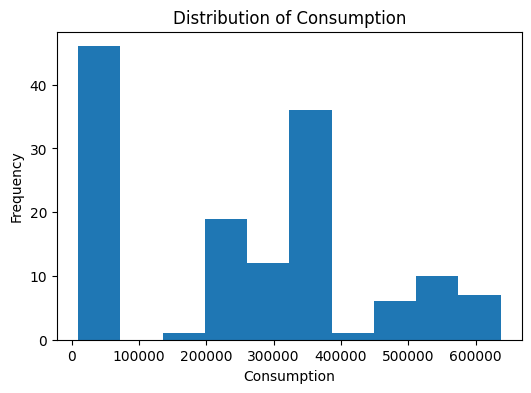

In [39]:
#Distribution of consumption
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(df["consumption"], bins=10)
plt.title("Distribution of Consumption")
plt.xlabel("Consumption")
plt.ylabel("Frequency")
plt.show()

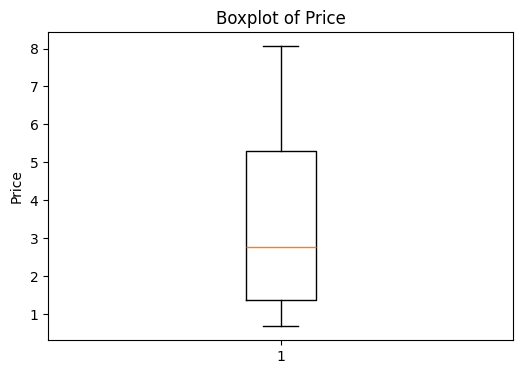

In [40]:
#Price distribution
plt.figure(figsize=(6,4))
plt.boxplot(df["price"])
plt.title("Boxplot of Price")
plt.ylabel("Price")
plt.show()

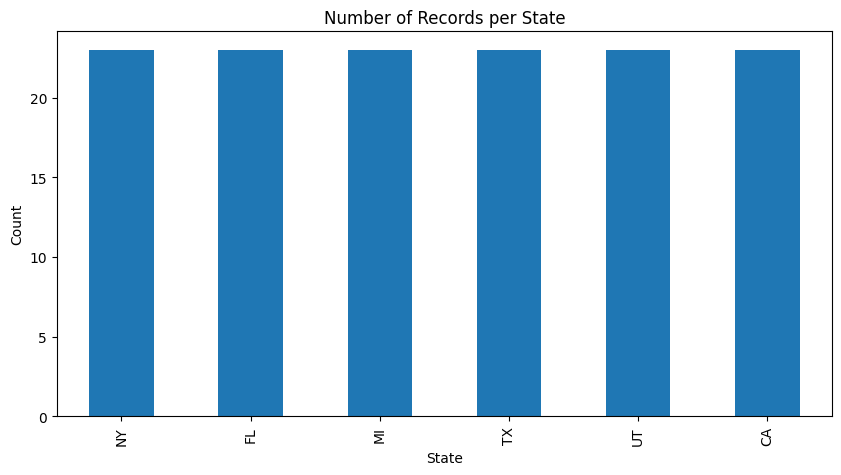

In [41]:
#States count
df["state"].value_counts().plot(kind="bar", figsize=(10,5))

plt.title("Number of Records per State")
plt.xlabel("State")
plt.ylabel("Count")
plt.show()

#Bivariate Analysis(Minimum 3 plots)

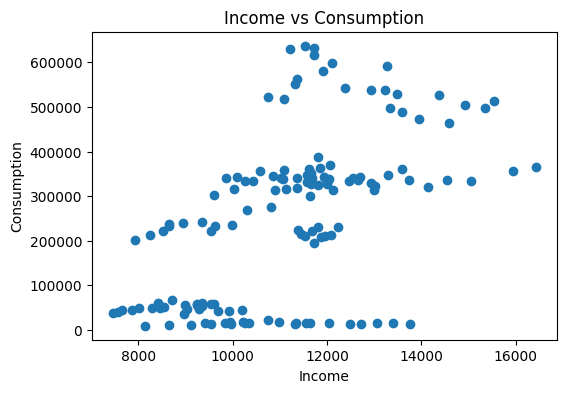

In [42]:
#Income Vs Consumption
plt.figure(figsize=(6,4))

plt.scatter(df["income"], df["consumption"])

plt.title("Income vs Consumption")
plt.xlabel("Income")
plt.ylabel("Consumption")

plt.show()

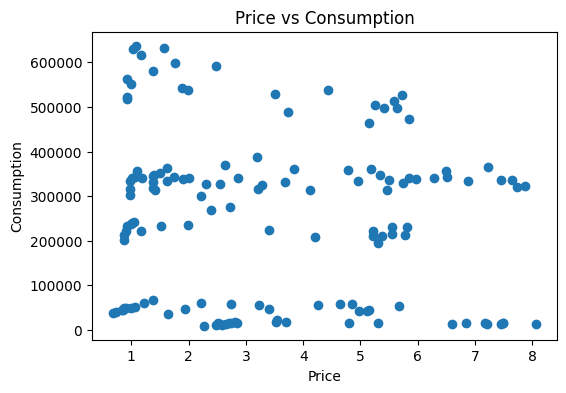

In [43]:
#Price Vs Consumption
plt.figure(figsize=(6,4))

plt.scatter(df["price"], df["consumption"])

plt.title("Price vs Consumption")
plt.xlabel("Price")
plt.ylabel("Consumption")

plt.show()

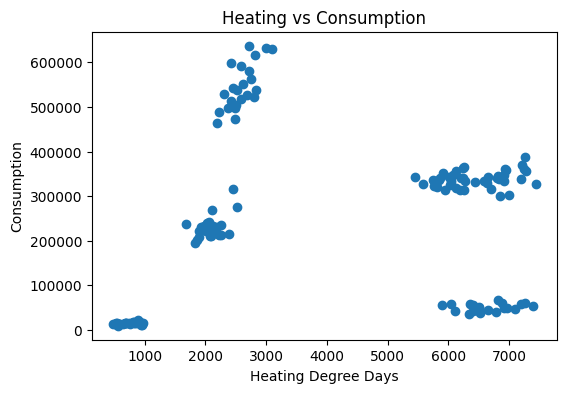

In [44]:
#Heating Vs Consumption
plt.figure(figsize=(6,4))

plt.scatter(df["heating"], df["consumption"])

plt.title("Heating vs Consumption")
plt.xlabel("Heating Degree Days")
plt.ylabel("Consumption")

plt.show()

#Multivariate Analysis(Minimum 3 plots)

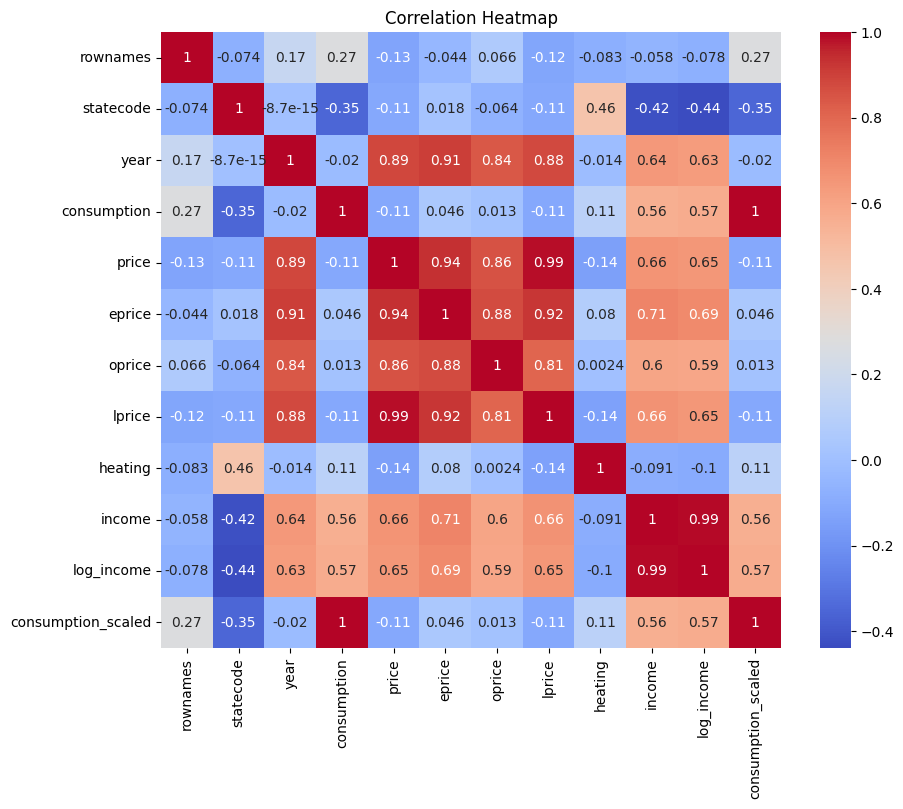

In [45]:
#Correlation Heatmap
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

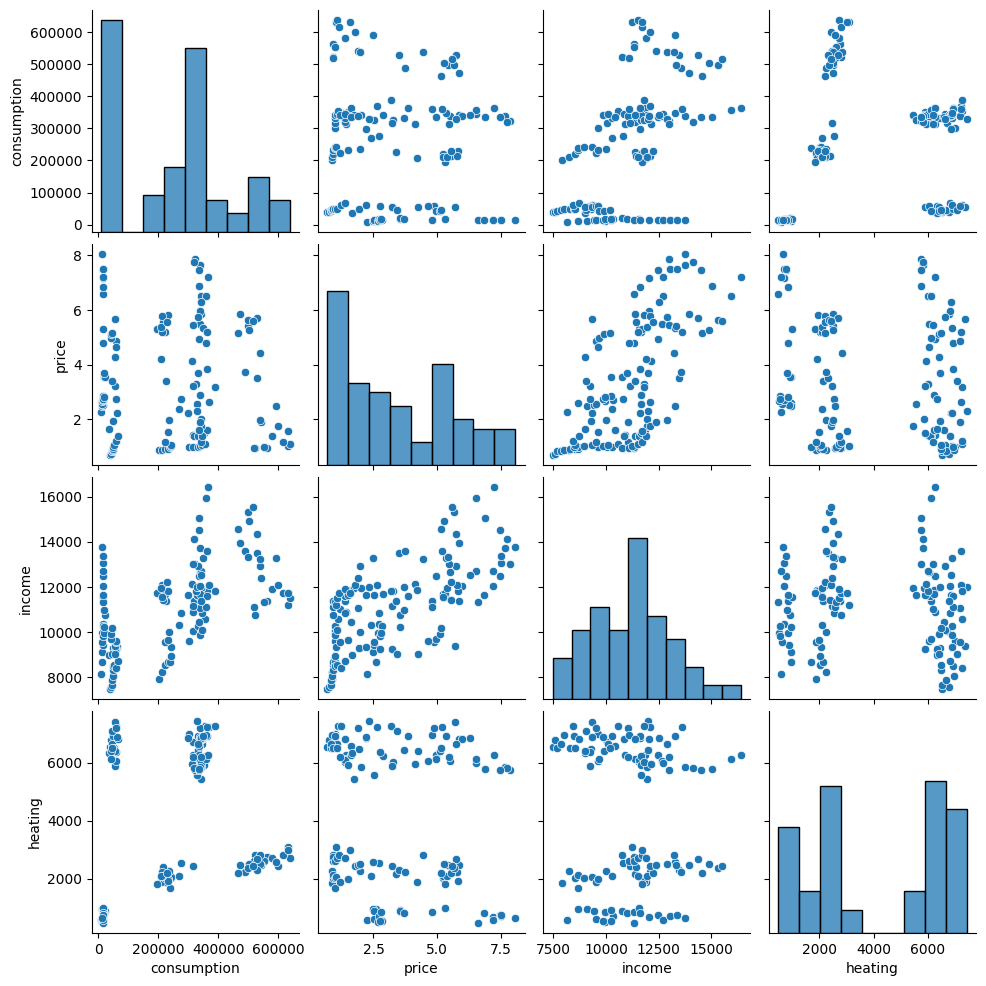

In [46]:
#Pair plot
sns.pairplot(
    df[
        [
            "consumption",
            "price",
            "income",
            "heating"
        ]
    ]
)

plt.show()

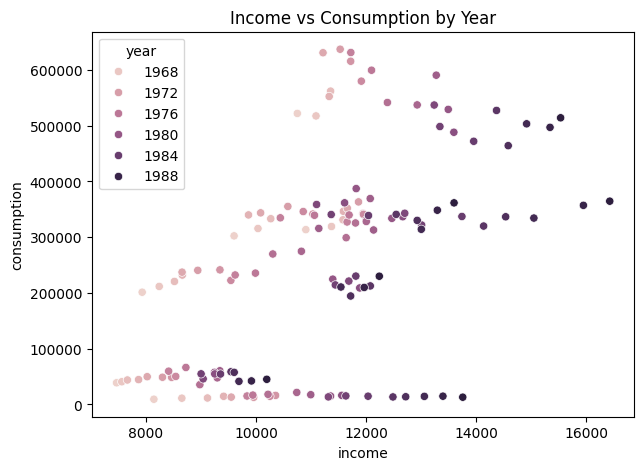

In [47]:
#Income Vs Consumption(colored by year)
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="income",
    y="consumption",
    hue="year"
)

plt.title("Income vs Consumption by Year")

plt.show()